In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [2]:
df=pd.read_csv("E:\Dataset\spam.csv")

In [3]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [5]:
df['spam']=df['Category'].apply(lambda x:1 if x=="spam" else 0)
df.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.Message,df.spam)

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
v=CountVectorizer()
x_train_count=v.fit_transform(x_train.values)
x_train_count.toarray()[:2]


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [8]:
x_train_count

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 55241 stored elements and shape (4179, 7422)>

In [9]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train_count,y_train)

MultinomialNB()

In [10]:
emails=[
    'K tell me anything about you.',
    'Thanks for your subscription to Ringtone UK your mobile will be charged Â£5/month Please confirm by replying YES or NO. If you reply NO you will not be charged'
]
emails_count=v.transform(emails)
model.predict(emails_count)

array([0, 1])

In [11]:
X_test_count=v.transform(x_test)
model.score(X_test_count,y_test)

0.9849246231155779

In [14]:
from sklearn.metrics import confusion_matrix
y_pred=model.predict(X_test_count)
cm=confusion_matrix(y_test,y_pred)
cm

array([[1197,    5],
       [  16,  175]])

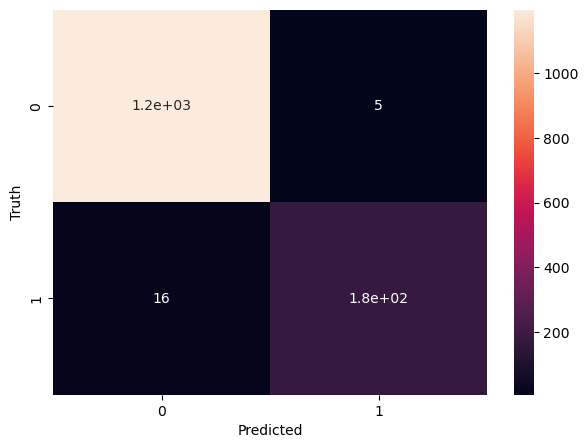

In [15]:
import seaborn as sns
plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()
plt.close()

In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1202
           1       0.97      0.92      0.94       191

    accuracy                           0.98      1393
   macro avg       0.98      0.96      0.97      1393
weighted avg       0.98      0.98      0.98      1393



Sklearn Pipeline

In [17]:
from sklearn.pipeline import Pipeline
clf=Pipeline([
    ('vectorizer',CountVectorizer()),
    ('nb',MultinomialNB())
])

In [18]:
clf.fit(x_train,y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [19]:
clf.score(x_test,y_test)

0.9849246231155779

In [20]:
clf.predict(emails)

array([0, 1])